In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.applications import DenseNet121,MobileNetV2
from tensorflow.keras.layers import Dense,Dropout,Conv2D,MaxPooling2D,Flatten,BatchNormalization,GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
train_dir = "/content/drive/MyDrive/Covid19-dataset/train"
test_dir = "/content/drive/MyDrive/Covid19-dataset/test"

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [ ]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=16,
    class_mode='sparse'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=16,
    class_mode='sparse',
    shuffle=False
)


Found 251 images belonging to 3 classes.
Found 66 images belonging to 3 classes.


In [ ]:
model = Sequential([
    MobileNetV2(weights='imagenet',include_top=False,input_shape=(224,224,3)),
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')
])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,619,203 (9.99 MB)

 Trainable params: 2,585,091 (9.86 MB)

 Non-trainable params: 34,112 (133.25 KB)

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    verbose=1
)

In [ ]:
history=model.fit(train_generator,validation_data=test_generator,epochs=20,callbacks=[early_stop,reduce_lr])

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 95s 4s/step - accuracy: 0.4741 - loss: 1.1037 - val_accuracy: 0.4242 - val_loss: 1.0242 - learning_rate: 1.0000e-04
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 61s 4s/step - accuracy: 0.6653 - loss: 0.7476 - val_accuracy: 0.4545 - val_loss: 0.9102 - learning_rate: 1.0000e-04
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 62s 4s/step - accuracy: 0.7649 - loss: 0.5986 - val_accuracy: 0.5455 - val_loss: 0.8184 - learning_rate: 1.0000e-04
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 62s 4s/step - accuracy: 0.8167 - loss: 0.4972 - val_accuracy: 0.6970 - val_loss: 0.6867 - learning_rate: 1.0000e-04
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 61s 4s/step - accuracy: 0.8645 - loss: 0.4122 - val_accuracy: 0.7273 - val_loss: 0.6542 - learning_rate: 1.0000e-04
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 62s 4s/step - accuracy: 0.8765 - loss: 0.3212 - val_accuracy: 0.6818 - val_loss: 0.6634 - learning_rate: 1.0000e-04
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 61s 4s/step - accuracy: 0.8845 - loss:

In [ ]:
loss, acc = model.evaluate(test_generator)

print("Test Accuracy:", acc)

5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 530ms/step - accuracy: 0.7121 - loss: 0.5624
Test Accuracy: 0.7121211886405945


In [ ]:
test_generator.reset()

pred = model.predict(test_generator)

y_pred = np.argmax(pred, axis=1)

from sklearn.metrics import classification_report

print(
    classification_report(
        test_generator.classes,
        y_pred,
        target_names=test_generator.class_indices.keys()
    )
)

5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step
                 precision    recall  f1-score   support

          Covid       0.92      0.85      0.88        26
         Normal       1.00      0.35      0.52        20
Viral Pneumonia       0.51      0.90      0.65        20

       accuracy                           0.71        66
      macro avg       0.81      0.70      0.68        66
   weighted avg       0.82      0.71      0.70        66



In [ ]:
model.save("covid_mobilenetv2.h5")

In [ ]:
from tensorflow.keras.models import load_model

model = load_model("covid_mobilenetv2.h5")

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving 0101.jpeg to 0101.jpeg


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Predicted Class: Viral Pneumonia
Confidence: 78.66762


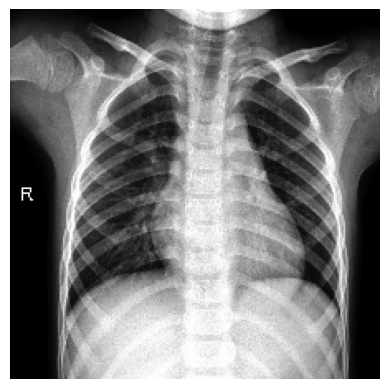

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing import image

img_path = list(uploaded.keys())[0]

img = image.load_img(
    img_path,
    target_size=(224,224)
)

img_array = image.img_to_array(img)

img_array = img_array / 255.0

img_array = np.expand_dims(
    img_array,
    axis=0
)

prediction = model.predict(img_array)

predicted_class = np.argmax(
    prediction,
    axis=1
)[0]

classes = [
    "Covid",
    "Normal",
    "Viral Pneumonia"
]

print(
    "Predicted Class:",
    classes[predicted_class]
)

print(
    "Confidence:",
    np.max(prediction)*100
)

plt.imshow(img)
plt.axis("off")
plt.show()